In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load raw data

In [9]:
df = pd.read_csv('../../data/raw/credit_data.csv')

In [10]:
df[df.duplicated()]

,step,customer,age,gender,zipcodeori,merchant,zipmerchant,category,amount,fraud


### Check for outliers
Do not remove during data preparation. Outliers are crutial for detecting anomalies such as fraud transactions.

In [ ]:
for col in cont_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')


plt.show()

### Check class distribution
If classes are imbalanced, avoid using Accuracy metric. Use F1 Score, Percision and Recall instead to measure model preformance.

In [11]:
# count values of classifier column
counts = df['fraud'].map({0: "No", 1: "Yes"}).value_counts()
counts

fraud
No     587442
Yes      7200
Name: count, dtype: int64

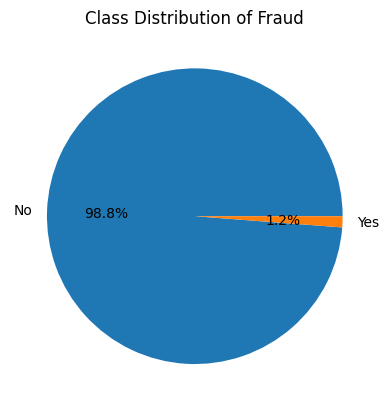

In [12]:
# pie chart
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Distribution of Fraud')
plt.show()

### Visual inspection
Scan though the data breifly looking for any other issues. 

In [ ]:
df[cont_cols].hist(figsize=(12, 10), bins=30)
plt.show()

In [ ]:
n_rows = int(np.ceil(len(binary_cols) / 2))

try:
    fig, axes = plt.subplots(int(n_rows), 2, figsize=(15, 5 * n_rows))
    axes = axes.flatten()
except:
    print("Error occurred while creating subplots.")

for ax, col in zip(axes, binary_cols):
    overall = df[col].map({0: "No", 1: "Yes"}).value_counts(normalize=True)
    overall = overall.reindex(["Yes", "No"], fill_value=0) * 100

    fraud_rate = df[df['fraud'] == 1][col].map({0: "No", 1: "Yes"}).value_counts(normalize=True)
    fraud_rate = fraud_rate.reindex(["Yes", "No"], fill_value=0) * 100

    plot_df = pd.DataFrame({
        "Overall %": overall,
        "Fraud %": fraud_rate
    })

    plot_df.plot(kind='bar', ax=ax)
    ax.set_title(col)

    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_ylabel("Percentage")

    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0)

    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f%%")

for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [ ]:
# Remove any identifier columns (When dataset is chosen)
# col_df = df.remove

### Variance Calculation


In [ ]:
col_var = df[cont_cols + binary_cols].var()
print(col_var)

### Correlation Calculation and Visualisation
Sees if any two features have a linear relationship.

In [ ]:
cor_cof= df[cont_cols + binary_cols + ['fraud']].corr()
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix

plt.figure(figsize=(10, 6))
sns.heatmap(cor_cof, mask=mask, annot=True, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns)
plt.title("Correlation between features")
plt.tight_layout()
plt.show()


In [ ]:
target_corr = cor_cof['fraud']
target_corr_cont = target_corr[cont_cols]

top2_vals = target_corr_cont.abs().sort_values(ascending=False)[1:3] #Find the top 2 features most correlated with fraud
print(top2_vals)

top2_features = top2_vals.index.to_list()

In [ ]:
f1, f2 = top2_features

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df[df['fraud'] == 0][f1],
    y=df[df['fraud'] == 0][f2],
    color="blue",
    label="Normal",
)

sns.scatterplot(
    x=df[df['fraud'] == 1][f1],
    y=df[df['fraud'] == 1][f2],
    color="orange",
    label="Fraud",
)
plt.show()

### Before data preparation

*Feature selection* - Are there features with no significance or zero variance?

*Feature scaling* - Are there numerical features with vastly different ranges?

*Data leakage* - Are there features that would not be available at the time of prediction but perfectly predict the output?

*Stratification* - Will the percentage of each class be roughly the same across data splits?

*Order* - Is your data time based? Can you shuffle it?

*Hidden bias* - Does data accurately represent the real world?
